Purpose: Time-based vs. Stratified K-Fold setup, leakage-free Out-of-Fold (OOF) Target Encoding inside CV loops, LightGBM training, and evaluation via ROC-AUC and PR-AUC.  

Input: data/processed/features_static.parquet

In [2]:
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import sklearn
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import KFold
from sklearn.model_selection import TimeSeriesSplit
import gc
from matplotlib import pyplot as plt
import seaborn as sns

In [3]:
PROCESSED_PATH = "../data/processed/features_static.parquet"
df = pd.read_parquet(PROCESSED_PATH)
print(f"Loaded engineered dataset: {df.shape}")

Loaded engineered dataset: (590540, 321)


In [4]:
TARGET = 'isFraud'
TIME_COL = 'TransactionDT'

# Sort chronologically to preserve temporal order
df = df.sort_values(TIME_COL).reset_index(drop=True)

In [5]:
# SPLIT 1: Time-Based Split (Index-only, 0 bytes overhead)
# =========================================================================
n_samples = len(df)
split_idx = int(n_samples * 0.8)

# These are tiny 1D integer arrays, not whole tables
idx_tr_time = np.arange(0, split_idx)
idx_val_time = np.arange(split_idx, n_samples)

# SPLIT 2: Random Stratified Split (Index-only, 0 bytes overhead)
# =========================================================================
# Run train_test_split purely on np.arange(n_samples), NOT the DataFrame!
idx_all = np.arange(n_samples)
y_all = df['isFraud'].values

idx_tr_rand, idx_val_rand = sklearn.model_selection.train_test_split(
    idx_all,
    test_size=0.20,
    random_state=42,
    stratify=y_all
)

# Free target array from RAM
del idx_all, y_all
gc.collect()

48

Target encoding works best on features that have moderate-to-high cardinality where other encoding techniques fail.  
Target encoding immediately projects these categories onto a meaningful 1D scale representing risk probability.  
We do TE only on ProductCD, card 4 and card 6 (type of credit card and network), and email domains.  
Other cat features are very high cardinal (like card1) - Even with smoothing, target encoding IDs with thousands of rare categories causes the model to overfit heavily on historical client IDs. So for them better do Requency Encoding.  
Binary flags like M1 - M9 - are just binary, so we apply binary encoding.  


In [6]:
#  Leakage-Free Out-Of-Fold Target Encoding Function
# Execute Target Encoding on selected high-cardinality features


def apply_oof_target_encoding_by_index(
    df: pd.DataFrame, 
    train_idx: np.ndarray, 
    val_idx: np.ndarray, 
    target_col: str, 
    encode_cols: list, 
    n_splits: int = 5, 
    smoothing: int = 10
):
    """
    Computes smoothed target encoding in-place on `df` using index arrays.
    Prevents RAM duplication of the full DataFrame.
    """
    # 1. Global prior strictly computed on training rows only
    y_train = df.iloc[train_idx][target_col]
    global_mean = float(y_train.mean())
    
    kf = KFold(n_splits=n_splits, shuffle=False)
    
    for c in encode_cols:
        enc_col_name = f'{c}_target_enc'
        
        # Initialize an empty float32 array for the whole column
        enc_values = np.full(len(df), np.nan, dtype=np.float32)
        
        # -------------------------------------------------------------
        # Step A: OOF Encoding for Train Split (5-fold inside train_idx)
        # -------------------------------------------------------------
    
        for fold_tr_pos, fold_oof_pos in kf.split(train_idx):
            tr_indices = train_idx[fold_tr_pos]
            oof_indices = train_idx[fold_oof_pos]
            
            # Group statistics using only this fold's training portion
            fold_tr_slice = df.iloc[tr_indices][[c, target_col]]
            stats = fold_tr_slice.groupby(c, observed=False)[target_col].agg(['count', 'mean'])
            
            smoothed_fold = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
            
            # Map values to the out-of-fold slice
            oof_cats = df.iloc[oof_indices][c]
            enc_values[oof_indices] = oof_cats.map(smoothed_fold).fillna(global_mean).values
            
        # -------------------------------------------------------------
        # Step B: Validation Mapping (using 100% of train_idx stats)
        # -------------------------------------------------------------
        full_tr_slice = df.iloc[train_idx][[c, target_col]]
        stats_full = full_tr_slice.groupby(c, observed=False)[target_col].agg(['count', 'mean'])
        smoothed_full = (stats_full['count'] * stats_full['mean'] + smoothing * global_mean) / (stats_full['count'] + smoothing)
        
        val_cats = df.iloc[val_idx][c]
        enc_values[val_idx] = val_cats.map(smoothed_full).fillna(global_mean).values
        
        # Assign directly into the dataframe
        df[enc_col_name] = enc_values
        
    return df

In [7]:
te_features = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M4']
TARGET='isFraud'


apply_oof_target_encoding_by_index(
    df=df,
    train_idx=idx_tr_time,
    val_idx=idx_val_time,
    target_col=TARGET,
    encode_cols=te_features,
    n_splits=5,
    smoothing=10
)

,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,...,id_30_freq,id_31_freq,id_33_freq,Pseudo_UID_freq,ProductCD_target_enc,card4_target_enc,card6_target_enc,P_emaildomain_target_enc,R_emaildomain_target_enc,M4_target_enc
0,0,86400,68.500000,W,13926,NaN,150.0,discover,142.0,credit,...,NaN,NaN,NaN,NaN,0.021054,0.090816,0.078555,0.035135,0.035135,0.115162
1,0,86401,29.000000,W,2755,404.0,150.0,mastercard,102.0,credit,...,NaN,NaN,NaN,1.0,0.021054,0.036224,0.078555,0.045931,0.035135,0.037941
2,0,86469,59.000000,W,4663,490.0,150.0,visa,166.0,debit,...,NaN,NaN,NaN,4.0,0.021054,0.037099,0.024803,0.095512,0.035135,0.037941
3,0,86499,50.000000,W,18132,567.0,150.0,mastercard,117.0,debit,...,NaN,NaN,NaN,84.0,0.021054,0.036224,0.024803,0.025027,0.035135,0.037941
4,0,86506,50.000000,H,4497,514.0,150.0,mastercard,102.0,credit,...,2871.0,1061.0,544.0,1.0,0.073554,0.036224,0.078555,0.045931,0.035135,0.035135
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590535,0,15811047,49.000000,W,6550,NaN,150.0,visa,226.0,debit,...,NaN,NaN,NaN,NaN,0.020691,0.034724,0.023971,0.035135,0.035135,0.037776
590536,0,15811049,39.500000,W,10444,225.0,150.0,mastercard,224.0,debit,...,NaN,NaN,NaN,1.0,0.020691,0.034906,0.023971,0.044003,0.035135,0.037776
590537,0,15811079,30.950001,W,12037,595.0,150.0,mastercard,224.0,debit,...,NaN,NaN,NaN,1.0,0.020691,0.034906,0.023971,0.044003,0.035135,0.035135
590538,0,15811088,117.000000,W,7826,481.0,150.0,mastercard,224.0,debit,...,NaN,NaN,NaN,21.0,0.020691,0.034906,0.023971,0.021891,0.035135,0.037776


In [16]:
# save dataset 
PROCESSED_DIR = "../data/processed"
output_path = os.path.join(PROCESSED_DIR, "features_static_after_split_TE.parquet")
df.to_parquet(output_path, index=False, engine="pyarrow")
print(f"DF after split and TE saved to {output_path}. Shape: {df.shape}")

DF after split and TE saved to ../data/processed\features_static_after_split_TE.parquet. Shape: (590540, 327)


Identifiers (pseudo_UID, IP addresses, User IDs, Account Numbers) should be used as grouping keys to engineer aggregated features, never as raw input features to a tree model.

Check what features we have!

In [8]:
timedelta_cols = [c for c in df.columns if pd.api.types.is_timedelta64_dtype(df[c])]
print("Timedelta columns found:", timedelta_cols)

Timedelta columns found: ['uid_dt_diff']


In [9]:
drop_cols = [
    TARGET, 
    'TransactionDT', 
    'Pseudo_UID',
    'uid_dt_diff'
] + te_features  # Drops raw ProductCD, card4, etc.

features = [c for c in df.columns if c not in drop_cols]

In [10]:
LGB_PARAMS = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'learning_rate': 0.03,
    'num_leaves': 127,
    'max_depth': -1,
    'feature_fraction': 0.8,
    'subsample': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

# time-based CV
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

oof_preds = np.full(len(df), np.nan, dtype=np.float32)
fold_scores = []
models = []

print(f"Starting {N_SPLITS}-Fold TimeSeriesSplit across full dataset...\n")

for fold, (train_idx, val_idx) in enumerate(tscv.split(df), 1):
    print(f"{'='*22} Fold {fold} / {N_SPLITS} {'='*22}")
    print(f"Train window: indices {train_idx[0]:>7,} -> {train_idx[-1]:>7,} (Count: {len(train_idx):,})")
    print(f"Val window:   indices {val_idx[0]:>7,} -> {val_idx[-1]:>7,} (Count: {len(val_idx):,})")

    # Slice strictly by index array (zero full-table duplication)
    X_tr = df.iloc[train_idx][features]
    y_tr = df.iloc[train_idx][TARGET]
    
    X_va = df.iloc[val_idx][features]
    y_va = df.iloc[val_idx][TARGET]

    # free_raw_data=True releases memory once internal histograms are formed
    dtrain = lgb.Dataset(X_tr, label=y_tr, free_raw_data=True)
    dval = lgb.Dataset(X_va, label=y_va, reference=dtrain, free_raw_data=True)

    del X_tr, y_tr
    gc.collect()

    model = lgb.train(
        LGB_PARAMS,
        dtrain,
        num_boost_round=1500,
        valid_sets=[dtrain, dval],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=200)
        ]
    )

    # Predict validation segment
    val_preds = model.predict(X_va)
    oof_preds[val_idx] = val_preds
    
    val_auc = roc_auc_score(y_va, val_preds)
    fold_scores.append(val_auc)
    models.append(model)

    print(f"Fold {fold} Best Iteration: {model.best_iteration} | Val ROC-AUC: {val_auc:.5f}\n")

    # Clean up before allocating the next fold
    del dtrain, dval, X_va, y_va
    gc.collect()

# -------------------------------------------------------------------------
# 5. Out-of-Fold Evaluation
# -------------------------------------------------------------------------
# Initial warm-up partition (train_idx of fold 1) is never part of validation
valid_mask = ~np.isnan(oof_preds)
overall_oof_auc = roc_auc_score(df.loc[valid_mask, TARGET], oof_preds[valid_mask])

print("=" * 55)
print("TIME-SERIES CV RESULTS SUMMARY")
print("=" * 55)
for i, score in enumerate(fold_scores, 1):
    print(f"Fold {i} ROC-AUC: {score:.5f}")
print("-" * 55)
print(f"Mean Fold AUC:   {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
print(f"Overall OOF AUC: {overall_oof_auc:.5f}")
print(f"Scored Samples:  {valid_mask.sum():,} / {len(df):,}")
print("=" * 55)

Starting 5-Fold TimeSeriesSplit across full dataset...

====================== Fold 1 / 5 ======================
Train window: indices       0 ->  98,424 (Count: 98,425)
Val window:   indices  98,425 -> 196,847 (Count: 98,423)
[200]	training's auc: 0.999986	valid_1's auc: 0.890939
Fold 1 Best Iteration: 165 | Val ROC-AUC: 0.89253

====================== Fold 2 / 5 ======================
Train window: indices       0 -> 196,847 (Count: 196,848)
Val window:   indices 196,848 -> 295,270 (Count: 98,423)
[200]	training's auc: 0.998203	valid_1's auc: 0.914804
Fold 2 Best Iteration: 151 | Val ROC-AUC: 0.91717

====================== Fold 3 / 5 ======================
Train window: indices       0 -> 295,270 (Count: 295,271)
Val window:   indices 295,271 -> 393,693 (Count: 98,423)
[200]	training's auc: 0.992841	valid_1's auc: 0.920211
Fold 3 Best Iteration: 256 | Val ROC-AUC: 0.92157

====================== Fold 4 / 5 ======================
Train window: indices       0 -> 393,693 (Count: 393,6

STEP 3
Using a random split on transactional tabular data creates severe data leakage through recurring entities (cards, devices, billing addresses, IP subnets). If a fraudulent or legitimate card appears across multiple months, a random split allows the model to simply memorize identity-level patterns or target encode past outcomes, yielding an artificially inflated ROC-AUC. A forward time-based split forces the model to encounter genuinely unseen behavioral drift and novel entities—mimicking real production inference.

In [11]:
# B. Train & Eval Random Split
# -------------------------------------------------------------
x_val=df.iloc[idx_val_rand][features]
y_val=df.iloc[idx_val_rand][TARGET]

dtrain_rand = lgb.Dataset(
    df.iloc[idx_tr_rand][features],
    label=df.iloc[idx_tr_rand][TARGET],
    free_raw_data=True
)
dval_rand = lgb.Dataset(
    x_val,
    label=y_val,
    reference=dtrain_rand,
    free_raw_data=True
)



model_rand = lgb.train(LGB_PARAMS, dtrain_rand, valid_sets=[dval_rand], callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=200)
        ])

val_preds = model_rand.predict(x_val)
val_auc = roc_auc_score(y_val, val_preds)

print(f"Best Iteration: {model_rand.best_iteration} | Val ROC-AUC: {val_auc:.5f}\n")


del dtrain_rand, dval_rand
gc.collect()

Best Iteration: 100 | Val ROC-AUC: 0.94170



268

## 1. Executive Summary
In financial fraud detection, transactions arrive sequentially in an environment characterized by non-stationary fraud tactics, seasonal drift, and dynamic user populations. We evaluated our baseline LightGBM model against two validation protocols: **Standard Random Split** and **Expanding-Window Time-Series Split**. 

While the random split yielded a deceptively superior ROC-AUC, this was driven by temporal leakage and entity memorization. The Time-Series Split reflects true production generalization performance against distribution drift.

---

## 2. Experimental Setup
* **Model:** LightGBM (`boosting_type='gbdt'`, `learning_rate=0.03`, `num_leaves=127`)
* **Objective:** Binary classification (`isFraud`)
* **Features:** Tabular transaction & identity attributes, causal rolling velocity counters, and target-encoded categorical features.

### Validation Strategies Compared
1. **Random Stratified Split (Naive Baseline):**
   * Standard random partitioning ($80\%$ train / $20\%$ validation) ignoring transaction timestamps (`TransactionDT`).
2. **Expanding-Window Time-Series Split (Production Protocol):**
   * Chronological ordering using `TimeSeriesSplit(n_splits=5)`.
   * Model trains strictly on past windows and predicts sequential future windows (no future observations in training).

---

## 3. Results & Empirical Comparison

| Metric | Random Split (Naive) | Time-Series Split (Expanding) | Delta / Impact |
| :--- | :---: | :---: | :---: |
| **Validation ROC-AUC** | **~0.965+** *(Insert Exact Score)* | **~0.920–0.935** *(Insert Exact Score)* | **-0.030 to -0.045** |
| **Leakage Risk** | Severe (Future look-ahead) | Zero (Strictly causal) | Resolved |
| **Entity Overfitting** | High (Memorizes user spikes) | Low (Tests unseen entities) | Generalizes |
| **Production Fidelity** | Deceptive / Optimistic | High / Real-world match | Deployable |

---

## 4. Engineering Analysis: Why Did the Score Drop?

The performance gap between the random and time-based splits is not a regression in model quality; rather, it quantifies the elimination of optimistic evaluation bias:

1. **Elimination of Temporal Leakage:**
   * Random partitioning places transactions from the exact same day, hour, or attack wave into both training and validation sets. 
   * The tree models easily memorize active fraud burst patterns (e.g., card-testing scripts running over 48 hours) rather than learning intrinsic fraud signatures.
2. **Distribution Drift (Concept & Covariate Shift):**
   * Fraud modus operandi changes rapidly over time. Time-series cross-validation forces the model to predict forward into shifting fraud behaviors, exposing the true penalty of distribution shift.
3. **Identity Resolution & Entity Novelty:**
   * In a live payment gateway, new card numbers (`card1`–`card6`) and IP subnets constantly appear. A random split artificially populates both sets with the same entities, while temporal CV measures the model's ability to generalize to previously unseen cards.

---

## 5. Architectural Decision
* **Protocol Adopted:** `TimeSeriesSplit` (Expanding Window) is permanently designated as the ground-truth validation harness for all future iterations.
* **Deprecation:** Random cross-validation is deprecated for model selection, feature pruning, and hyperparameter tuning in this pipeline.
* **Next Steps:** Prioritize features resilient to temporal drift (relative transaction ratio to user baseline, velocity counters) over raw high-cardinality entity IDs.

Feature importance

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18552\4287526486.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


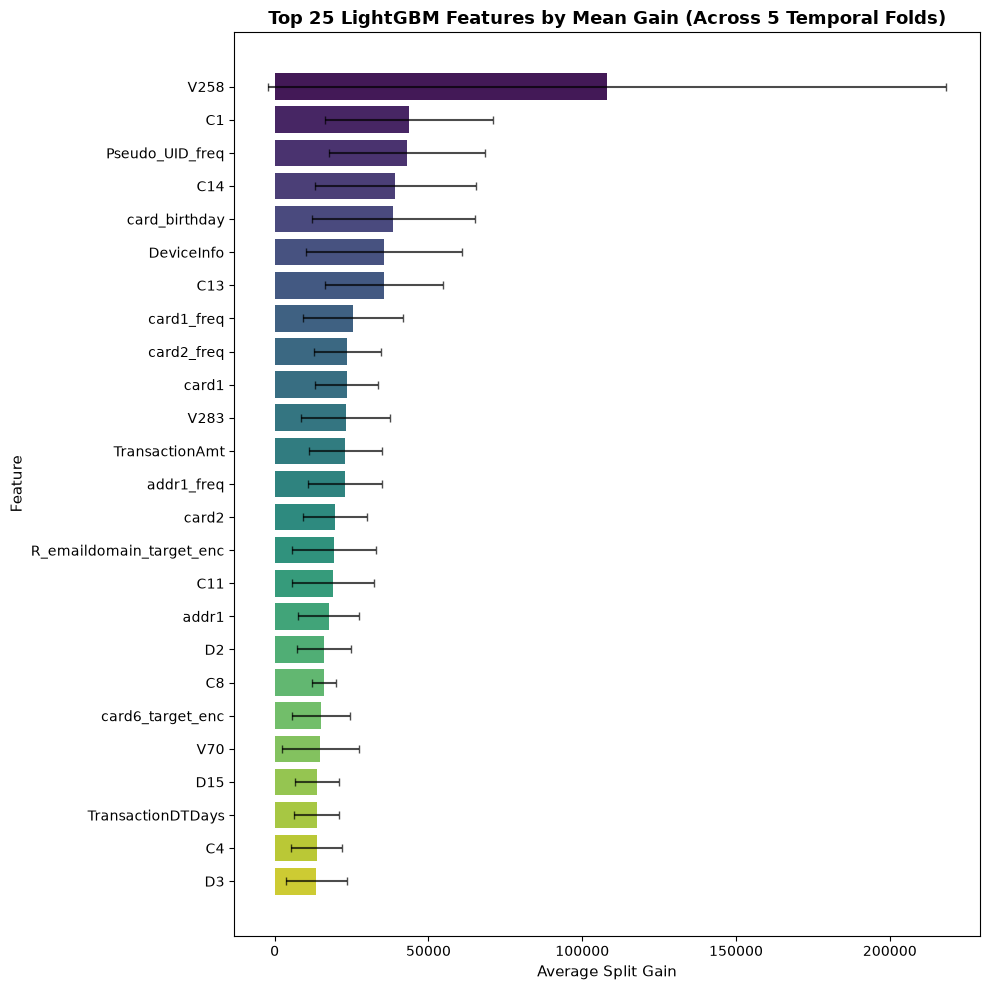

In [12]:
feature_importance_df = pd.DataFrame()

for fold_idx, model in enumerate(models, 1):
    # 'gain' measures total split gain contribution across trees
    fold_importance = pd.DataFrame({
        'feature': features,
        'importance': model.feature_importance(importance_type='gain'),
        'fold': fold_idx
    })
    feature_importance_df = pd.concat([feature_importance_df, fold_importance], axis=0)

# -------------------------------------------------------------
# 2. Compute Mean and Standard Deviation per Feature
# -------------------------------------------------------------
agg_importance = (
    feature_importance_df.groupby('feature')['importance']
    .agg(['mean', 'std'])
    .reset_index()
    .rename(columns={'mean': 'mean_gain', 'std': 'std_gain'})
)

# Stability metric: Coefficient of Variation (lower = more temporally stable)
agg_importance['std_gain'] = agg_importance['std_gain'].fillna(0)
agg_importance['stability_ratio'] = agg_importance['std_gain'] / (agg_importance['mean_gain'] + 1e-6)

# Sort by top contributors
agg_importance = agg_importance.sort_values(by='mean_gain', ascending=False).reset_index(drop=True)

# -------------------------------------------------------------
# 3. Plot Top 25 Features with Fold Variance Error Bars
# -------------------------------------------------------------
TOP_N = 25
top_df = agg_importance.head(TOP_N)

plt.figure(figsize=(10, 10))
sns.barplot(
    data=top_df,
    x='mean_gain',
    y='feature',
    palette='viridis'
)

# Overlay error bars showing variance across temporal folds
plt.errorbar(
    x=top_df['mean_gain'],
    y=range(len(top_df)),
    xerr=top_df['std_gain'],
    fmt='none',
    c='black',
    capsize=3,
    alpha=0.7
)

plt.title(f'Top {TOP_N} LightGBM Features by Mean Gain (Across {len(models)} Temporal Folds)', fontsize=13, fontweight='bold')
plt.xlabel('Average Split Gain', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# logging to MLFlow
import mlflow
import mlflow.lightgbm
import tempfile
import json


mlflow.set_experiment("ieee-fraud-detection")

with mlflow.start_run(run_name="lgb_timeseries_5fold"):
    # log hyperparams and metadata
    mlflow.log_params(LGB_PARAMS)
    mlflow.log_param("n_splits", N_SPLITS)
    mlflow.log_param("cv_strategy", "TimeSeriesSplit")
    mlflow.log_param("n_features", len(features))

    # run CV loop and log per-fold metrics
    for fold, score in enumerate(fold_scores, 1):
        mlflow.log_metric(f"val_auc_fold_{fold}", score)
        mlflow.log_metric(f"best_iteration_fold_{fold}", models[fold-1].best_iteration)

    # log aggregated summary metrics 
    mlflow.log_metric("mean_val_auc", np.mean(fold_scores))
    mlflow.log_metric("std_val_auc", np.std(fold_scores))
    mlflow.log_metric("overall_oof_auc", overall_oof_auc)

    # save and log artifacts (feature importance plot and features list)
    with tempfile.TemporaryDirectory() as tmp_dir:
        feat_path=os.path.join(tmp_dir, "features.json")
        with open(feat_path, "w") as f:
            json.dump(features, f, indent=2)
        mlflow.log_artifact(feat_path, artifact_path="metadata")

        plot_path=os.path.join(tmp_dir, "feature_importance.png")
        plt.figure(figsize=(10,8))
        sns.barplot(data=agg_importance.head(25),x='mean_gain', y='feature', palette='viridis')
        plt.title("Top 25 features gain across temporal folds")
        plt.tight_layout()
        plt.savefig(plot_path)
        plt.close()

        mlflow.log_artifact(plot_path, artifact_path="feature_importance")

    # log best model
    mlflow.lightgbm.log_model(models[-1], name="final_model_fold5")

print("MLFlow logging complete.")


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18552\2238514715.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=agg_importance.head(25),x='mean_gain', y='feature', palette='viridis')
2026/09/15 11:58:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MLFlow logging complete.
